# 06: TRAIN XGBOOST MODEL

This notebook trains XGBoost regression models to predict Land Surface Temperature (LST) from satellite and street-level imagery features. Two models are trained: a full model with GSV features and a deployment model using only raster features.

## MODULE SETUP

In [1]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os

# Set working directory to project folder.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/hot_hem"
os.chdir(BASE_DIR)

print(f"Working directory: {BASE_DIR}")

Working directory: /content/drive/MyDrive/Colab Notebooks/hot_hem


## IMPORT SETUP

In [3]:
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

## PATH CONFIGURATION

In [4]:
# Input path.
TRAIN_FILE = Path("data/outputs/features/gsv_with_raster_features.csv")

# Output paths.
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents = True, exist_ok = True)

FULL_MODEL = MODEL_DIR / "xgboost_full_model.pkl"
DEPLOYMENT_MODEL = MODEL_DIR / "xgboost_deployment_model.pkl"
FEATURE_IMPORTANCE = MODEL_DIR / "feature_importance.csv"

print("PATH CONFIGURATION")
print(f"Training data: {TRAIN_FILE}")
print(f"Model directory: {MODEL_DIR}")

PATH CONFIGURATION
Training data: data/outputs/features/gsv_with_raster_features.csv
Model directory: models


## LOAD TRAINING DATA

In [5]:
# Load training data.
df = pd.read_csv(TRAIN_FILE)

print(f"Loaded {len(df)} training records.")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 22878 training records.
Columns: ['uid', 'lat', 'lon', 'heading', 'district', 'ward', 'pct_other', 'pct_vegetation', 'pct_sky', 'pct_building', 'pct_pavement_road', 'pct_water', 'pct_vehicle_clutter', 'gvi', 'svi', 'bvi', 'hardscape_index', 'lst_kelvin', 'lst_celsius', 'ndvi', 'emissivity', 'palsar_hh_db', 'palsar_hv_db', 'palsar_hv_hh_ratio', 'palsar_glcm_contrast', 'palsar_glcm_homogeneity', 'palsar_glcm_energy', 'elevation_m', 'sky_view_factor', 'landcover_class']


,uid,lat,lon,heading,district,ward,pct_other,pct_vegetation,pct_sky,pct_building,...,emissivity,palsar_hh_db,palsar_hv_db,palsar_hv_hh_ratio,palsar_glcm_contrast,palsar_glcm_homogeneity,palsar_glcm_energy,elevation_m,sky_view_factor,landcover_class
0,2964,10.780083,106.699229,42.511501,District 1,Ben Thanh,0.882522,0.005999,0.000005,0.004031,...,2.7733,-1.812519,-6.715048,3.704816,2468.15,0.019243,0.158114,16.0,0.982801,2.0
1,2965,10.780415,106.699539,42.511501,District 1,Ben Thanh,0.743867,0.042512,0.000090,0.002720,...,2.7743,-4.105413,-7.038041,1.714332,1629.90,0.018135,0.158114,17.0,0.991037,2.0
2,2966,10.780747,106.699849,42.511501,District 1,Ben Thanh,0.841379,0.005420,0.000000,0.003713,...,2.7700,0.244117,-8.934172,-36.597968,4893.60,0.006264,0.158114,20.0,0.999020,2.0
3,2967,10.780083,106.699229,133.624199,District 1,Ben Thanh,0.894475,0.006035,0.000115,0.003193,...,2.7733,-1.812519,-6.715048,3.704816,2468.15,0.019243,0.158114,16.0,0.982801,2.0
4,2968,10.779772,106.699561,133.624199,District 1,Ben Thanh,0.910073,0.000784,0.000000,0.004768,...,2.7786,-8.977279,-14.781083,1.646499,5323.70,0.010631,0.158114,16.0,0.982814,2.0


In [6]:
# Define target variable.
target = "lst_celsius"

print(f"Target variable: {target}")
print(f"Target statistics:")
print(df[target].describe())

Target variable: lst_celsius
Target statistics:
count    22878.000000
mean        40.455007
std          1.526355
min         33.461755
25%         39.538965
50%         40.601984
75%         41.429163
max         46.539087
Name: lst_celsius, dtype: float64


## DEFINE FEATURE CATEGORIES

In [7]:
# Landsat features: thermal and vegetation indices.
LANDSAT_FEATURES = [
    "ndvi",
    "emissivity"
]

# PALSAR features: radar backscatter and texture.
PALSAR_FEATURES = [
    "palsar_hh_db",
    "palsar_hv_db",
    "palsar_hv_hh_ratio",
    "palsar_glcm_contrast",
    "palsar_glcm_homogeneity",
    "palsar_glcm_energy"
]

# DSM features: elevation and sky view.
DSM_FEATURES = [
    "elevation_m",
    "sky_view_factor"
]

# Landcover features.
LANDCOVER_FEATURES = [
    "landcover_class"
]

# GSV segmentation features: visual indices from street imagery.
GSV_SEGMENTATION_FEATURES = [
    "pct_vegetation",
    "pct_water",
]

# GSV derived features: computed indices.
GSV_DERIVED_FEATURES = [
    "gvi",
    "svi",
    "bvi",
    "hardscape_index"
]

# Location features: administrative boundaries.
LOCATION_FEATURES = [
    "district",
    "ward"
]

# Shared features: available for both GSV points and network nodes.
SHARED_FEATURES = (
    LANDSAT_FEATURES +
    PALSAR_FEATURES +
    DSM_FEATURES +
    LANDCOVER_FEATURES
)

# GSV-only features: only available at GSV sample points.
GSV_ONLY_FEATURES = (
    GSV_SEGMENTATION_FEATURES +
    GSV_DERIVED_FEATURES +
    LOCATION_FEATURES
)

# All features: complete feature set for full model.
ALL_FEATURES = SHARED_FEATURES + GSV_ONLY_FEATURES

print("FEATURE CATEGORIES")
print(f"Shared features (raster only): {len(SHARED_FEATURES)}")
print(f"GSV-only features: {len(GSV_ONLY_FEATURES)}")
print(f"Total features: {len(ALL_FEATURES)}")

FEATURE CATEGORIES
Shared features (raster only): 11
GSV-only features: 8
Total features: 19


## PREPARE TRAINING DATA

In [8]:
# Filter to rows with valid target.
df_train = df[df[target].notna()].copy()

print(f"Samples with valid LST: {len(df_train)} / {len(df)} ({len(df_train)/len(df)*100:.1f}%)")

# Check available features.
available_all = [f for f in ALL_FEATURES if f in df_train.columns]
available_shared = [f for f in SHARED_FEATURES if f in df_train.columns]

print(f"Available features:")
print(f"Full model: {len(available_all)} / {len(ALL_FEATURES)}")
print(f"Deployment model: {len(available_shared)} / {len(SHARED_FEATURES)}")

# Show missing features.
missing_all = set(ALL_FEATURES) - set(available_all)
if missing_all:
    print(f"Missing features: {missing_all}")

# Update feature lists.
ALL_FEATURES = available_all
SHARED_FEATURES = available_shared

Samples with valid LST: 22878 / 22878 (100.0%)
Available features:
Full model: 19 / 19
Deployment model: 11 / 11


In [9]:
# One-hot encode categorical features.
if "district" in df_train.columns:
    district_dummies = pd.get_dummies(df_train["district"], prefix = "district", drop_first = True)
    df_train = pd.concat([df_train, district_dummies], axis = 1)
    print(f"Created {len(district_dummies.columns)} district dummy variables.")

    # Update feature list.
    ALL_FEATURES = [f for f in ALL_FEATURES if f != "district"] + district_dummies.columns.tolist()

if "ward" in df_train.columns:
    ward_dummies = pd.get_dummies(df_train["ward"], prefix = "ward", drop_first = True)
    df_train = pd.concat([df_train, ward_dummies], axis = 1)
    print(f"Created {len(ward_dummies.columns)} ward dummy variables.")

    # Update feature list.
    ALL_FEATURES = [f for f in ALL_FEATURES if f != "ward"] + ward_dummies.columns.tolist()

print(f"Features after encoding: {len(ALL_FEATURES)}")

Created 2 district dummy variables.
Created 5 ward dummy variables.
Features after encoding: 24


In [10]:
# Check feature completeness.
print("FEATURE COMPLETENESS")
print("")
for feat in ALL_FEATURES:
    if feat in df_train.columns:
        completeness = df_train[feat].notna().sum() / len(df_train) * 100
        print(f"{feat:35s}: {completeness:5.1f}%")

FEATURE COMPLETENESS

ndvi                               : 100.0%
emissivity                         : 100.0%
palsar_hh_db                       : 100.0%
palsar_hv_db                       : 100.0%
palsar_hv_hh_ratio                 : 100.0%
palsar_glcm_contrast               : 100.0%
palsar_glcm_homogeneity            : 100.0%
palsar_glcm_energy                 : 100.0%
elevation_m                        : 100.0%
sky_view_factor                    : 100.0%
landcover_class                    : 100.0%
pct_vegetation                     : 100.0%
pct_water                          : 100.0%
gvi                                : 100.0%
svi                                : 100.0%
bvi                                : 100.0%
hardscape_index                    : 100.0%
district_District 2                : 100.0%
district_District 8                : 100.0%
ward_Binh An                       : 100.0%
ward_Co Giang                      : 100.0%
ward_Thao Dien                     : 100.0%
ward_Ward 

## XGBOOST PARAMETERS

In [11]:
# Define XGBoost hyperparameters.
xgb_params_full = {
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 3,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "early_stopping_rounds": 50
}

print("XGBOOST PARAMETERS")
for key, value in xgb_params_full.items():
    print(f"{key}: {value}")

XGBOOST PARAMETERS
n_estimators: 500
max_depth: 6
learning_rate: 0.05
subsample: 0.8
colsample_bytree: 0.8
min_child_weight: 3
reg_alpha: 0.1
reg_lambda: 1.0
random_state: 42
n_jobs: -1
early_stopping_rounds: 50


## TRAIN FULL MODEL

In [12]:
print("TRAINING FULL MODEL (WITH GSV FEATURES)")

# Prepare feature matrix and target.
X_full = df_train[ALL_FEATURES].copy()
y_full = df_train[target].copy()

print(f"Training samples: {len(X_full)}")
print(f"Features: {len(ALL_FEATURES)}")

TRAINING FULL MODEL (WITH GSV FEATURES)
Training samples: 22878
Features: 24


In [13]:
# Cross-validation.
print("10-fold cross-validation.")

kfold = KFold(n_splits = 10, shuffle = True, random_state = 42)
fold_metrics = []

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_full), 1):
    print(f"Fold {fold_idx}/10")

    # Split data.
    X_train_fold = X_full.iloc[train_idx]
    y_train_fold = y_full.iloc[train_idx]
    X_val_fold = X_full.iloc[val_idx]
    y_val_fold = y_full.iloc[val_idx]

    # Train model.
    model_fold = xgb.XGBRegressor(**xgb_params_full)
    model_fold.fit(
        X_train_fold,
        y_train_fold,
        eval_set = [(X_val_fold, y_val_fold)],
        verbose = False
    )

    # Make predictions.
    y_pred_fold = model_fold.predict(X_val_fold)

    # Calculate metrics.
    rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
    r2 = r2_score(y_val_fold, y_pred_fold)
    mae = mean_absolute_error(y_val_fold, y_pred_fold)

    print(f"RMSE: {rmse:.4f}, R2: {r2:.4f}, MAE: {mae:.4f}")

    fold_metrics.append({
        "fold": fold_idx,
        "rmse": rmse,
        "r2": r2,
        "mae": mae
    })

# Calculate average metrics.
avg_rmse = np.mean([m["rmse"] for m in fold_metrics])
avg_r2 = np.mean([m["r2"] for m in fold_metrics])
avg_mae = np.mean([m["mae"] for m in fold_metrics])
std_rmse = np.std([m["rmse"] for m in fold_metrics])
std_r2 = np.std([m["r2"] for m in fold_metrics])
std_mae = np.std([m["mae"] for m in fold_metrics])

print("")
print("CROSS-VALIDATION RESULTS (FULL MODEL)")
print(f"RMSE: {avg_rmse:.4f} +/- {std_rmse:.4f}")
print(f"R2: {avg_r2:.4f} +/- {std_r2:.4f}")
print(f"MAE: {avg_mae:.4f} +/- {std_mae:.4f}")

10-fold cross-validation.
Fold 1/10
RMSE: 0.6166, R2: 0.8385, MAE: 0.4475
Fold 2/10
RMSE: 0.6014, R2: 0.8350, MAE: 0.4439
Fold 3/10
RMSE: 0.6110, R2: 0.8436, MAE: 0.4437
Fold 4/10
RMSE: 0.6200, R2: 0.8358, MAE: 0.4423
Fold 5/10
RMSE: 0.6357, R2: 0.8350, MAE: 0.4477
Fold 6/10
RMSE: 0.6215, R2: 0.8390, MAE: 0.4407
Fold 7/10
RMSE: 0.5981, R2: 0.8408, MAE: 0.4333
Fold 8/10
RMSE: 0.6147, R2: 0.8336, MAE: 0.4481
Fold 9/10
RMSE: 0.6095, R2: 0.8446, MAE: 0.4443
Fold 10/10
RMSE: 0.6368, R2: 0.8207, MAE: 0.4560

CROSS-VALIDATION RESULTS (FULL MODEL)
RMSE: 0.6165 +/- 0.0121
R2: 0.8367 +/- 0.0064
MAE: 0.4448 +/- 0.0056


In [15]:
# Train final model on all data.
# Remove early_stopping_rounds since no validation set is used for final model.
xgb_params_final = {k: v for k, v in xgb_params_full.items() if k != "early_stopping_rounds"}

model_full = xgb.XGBRegressor(**xgb_params_final)
model_full.fit(X_full, y_full, verbose = False)

# Training metrics.
y_pred_full = model_full.predict(X_full)
train_rmse = np.sqrt(mean_squared_error(y_full, y_pred_full))
train_r2 = r2_score(y_full, y_pred_full)

print("Training set performance:")
print(f"RMSE: {train_rmse:.4f}")
print(f"R2: {train_r2:.4f}")

Training set performance:
RMSE: 0.4630
R2: 0.9080


In [16]:
# Feature importance for full model.
print("FEATURE IMPORTANCE (FULL MODEL)")

importance_full = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance": model_full.feature_importances_
}).sort_values("importance", ascending = False)

print("Top 20 features:")
for idx, row in importance_full.head(20).iterrows():
    print(f"{row['feature']:35s}: {row['importance']:.4f}")

FEATURE IMPORTANCE (FULL MODEL)
Top 20 features:
district_District 8                : 0.3010
ndvi                               : 0.1244
emissivity                         : 0.0939
landcover_class                    : 0.0833
ward_Co Giang                      : 0.0640
ward_Binh An                       : 0.0624
district_District 2                : 0.0616
ward_Ward 6                        : 0.0371
elevation_m                        : 0.0345
ward_Thao Dien                     : 0.0242
ward_Ward 5                        : 0.0222
sky_view_factor                    : 0.0159
palsar_hv_db                       : 0.0111
palsar_hh_db                       : 0.0109
palsar_glcm_contrast               : 0.0082
palsar_glcm_homogeneity            : 0.0077
palsar_hv_hh_ratio                 : 0.0074
palsar_glcm_energy                 : 0.0050
bvi                                : 0.0044
pct_water                          : 0.0044


## TRAIN DEPLOYMENT MODEL

In [17]:
print("TRAINING DEPLOYMENT MODEL (SHARED FEATURES ONLY)")

# Prepare feature matrix with shared features only.
X_deploy = df_train[SHARED_FEATURES].copy()
y_deploy = df_train[target].copy()

print(f"Training samples: {len(X_deploy)}")
print(f"Features: {len(SHARED_FEATURES)}")

TRAINING DEPLOYMENT MODEL (SHARED FEATURES ONLY)
Training samples: 22878
Features: 11


In [18]:
# Cross-validation.
print("10-fold cross-validation.")

xgb_params_deploy = xgb_params_full.copy()
fold_metrics_deploy = []

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_deploy), 1):
    print(f"Fold {fold_idx}/10")

    # Split data.
    X_train_fold = X_deploy.iloc[train_idx]
    y_train_fold = y_deploy.iloc[train_idx]
    X_val_fold = X_deploy.iloc[val_idx]
    y_val_fold = y_deploy.iloc[val_idx]

    # Train model.
    model_fold = xgb.XGBRegressor(**xgb_params_deploy)
    model_fold.fit(
        X_train_fold,
        y_train_fold,
        eval_set = [(X_val_fold, y_val_fold)],
        verbose = False
    )

    # Make predictions.
    y_pred_fold = model_fold.predict(X_val_fold)

    # Calculate metrics.
    rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
    r2 = r2_score(y_val_fold, y_pred_fold)
    mae = mean_absolute_error(y_val_fold, y_pred_fold)

    print(f"RMSE: {rmse:.4f}, R2: {r2:.4f}, MAE: {mae:.4f}")

    fold_metrics_deploy.append({
        "fold": fold_idx,
        "rmse": rmse,
        "r2": r2,
        "mae": mae
    })

# Calculate average metrics.
avg_rmse_deploy = np.mean([m["rmse"] for m in fold_metrics_deploy])
avg_r2_deploy = np.mean([m["r2"] for m in fold_metrics_deploy])
avg_mae_deploy = np.mean([m["mae"] for m in fold_metrics_deploy])
std_rmse_deploy = np.std([m["rmse"] for m in fold_metrics_deploy])
std_r2_deploy = np.std([m["r2"] for m in fold_metrics_deploy])
std_mae_deploy = np.std([m["mae"] for m in fold_metrics_deploy])

print("")
print("CROSS-VALIDATION RESULTS (DEPLOYMENT MODEL)")
print(f"RMSE: {avg_rmse_deploy:.4f} +/- {std_rmse_deploy:.4f}")
print(f"R2: {avg_r2_deploy:.4f} +/- {std_r2_deploy:.4f}")
print(f"MAE: {avg_mae_deploy:.4f} +/- {std_mae_deploy:.4f}")

10-fold cross-validation.
Fold 1/10
RMSE: 0.6859, R2: 0.8001, MAE: 0.4798
Fold 2/10
RMSE: 0.6654, R2: 0.7980, MAE: 0.4777
Fold 3/10
RMSE: 0.6900, R2: 0.8006, MAE: 0.4906
Fold 4/10
RMSE: 0.7001, R2: 0.7906, MAE: 0.4899
Fold 5/10
RMSE: 0.7019, R2: 0.7989, MAE: 0.4928
Fold 6/10
RMSE: 0.6987, R2: 0.7966, MAE: 0.4981
Fold 7/10
RMSE: 0.6572, R2: 0.8078, MAE: 0.4726
Fold 8/10
RMSE: 0.6693, R2: 0.8027, MAE: 0.4845
Fold 9/10
RMSE: 0.6859, R2: 0.8032, MAE: 0.4891
Fold 10/10
RMSE: 0.7332, R2: 0.7623, MAE: 0.5186

CROSS-VALIDATION RESULTS (DEPLOYMENT MODEL)
RMSE: 0.6888 +/- 0.0208
R2: 0.7961 +/- 0.0120
MAE: 0.4894 +/- 0.0122


In [19]:
# Train final model on all data.
# Remove early_stopping_rounds since no validation set is used for final model.
model_deploy = xgb.XGBRegressor(**xgb_params_final)
model_deploy.fit(X_deploy, y_deploy, verbose = False)

# Training metrics.
y_pred_deploy = model_deploy.predict(X_deploy)
train_rmse_deploy = np.sqrt(mean_squared_error(y_deploy, y_pred_deploy))
train_r2_deploy = r2_score(y_deploy, y_pred_deploy)

print("Training set performance:")
print(f"RMSE: {train_rmse_deploy:.4f}")
print(f"R2: {train_r2_deploy:.4f}")

Training set performance:
RMSE: 0.5483
R2: 0.8709


In [20]:
# Feature importance for deployment model.
print("FEATURE IMPORTANCE (DEPLOYMENT MODEL)")

importance_deploy = pd.DataFrame({
    "feature": SHARED_FEATURES,
    "importance": model_deploy.feature_importances_
}).sort_values("importance", ascending = False)

for idx, row in importance_deploy.iterrows():
    print(f"{row['feature']:35s}: {row['importance']:.4f}")

FEATURE IMPORTANCE (DEPLOYMENT MODEL)
emissivity                         : 0.3046
landcover_class                    : 0.2319
ndvi                               : 0.2085
elevation_m                        : 0.0660
sky_view_factor                    : 0.0375
palsar_hv_db                       : 0.0327
palsar_hh_db                       : 0.0317
palsar_glcm_contrast               : 0.0249
palsar_hv_hh_ratio                 : 0.0231
palsar_glcm_homogeneity            : 0.0208
palsar_glcm_energy                 : 0.0181


## MODEL COMPARISON

In [21]:
print("MODEL PERFORMANCE COMPARISON")
print("")

comparison = pd.DataFrame({
    "Model": ["Full (with GSV)", "Deployment (raster only)"],
    "Features": [len(ALL_FEATURES), len(SHARED_FEATURES)],
    "CV RMSE": [f"{avg_rmse:.4f} +/- {std_rmse:.4f}", f"{avg_rmse_deploy:.4f} +/- {std_rmse_deploy:.4f}"],
    "CV R2": [f"{avg_r2:.4f} +/- {std_r2:.4f}", f"{avg_r2_deploy:.4f} +/- {std_r2_deploy:.4f}"],
})

print(comparison.to_string(index = False))

# Performance gap.
rmse_gap = avg_rmse_deploy - avg_rmse
r2_gap = avg_r2 - avg_r2_deploy

print("")
print("Performance gap from removing GSV features:")
print(f"RMSE increase: +{rmse_gap:.4f} ({rmse_gap/avg_rmse*100:.1f}%)")
print(f"R2 decrease: -{r2_gap:.4f} ({r2_gap/avg_r2*100:.1f}%)")

MODEL PERFORMANCE COMPARISON

                   Model  Features           CV RMSE             CV R2
         Full (with GSV)        24 0.6165 +/- 0.0121 0.8367 +/- 0.0064
Deployment (raster only)        11 0.6888 +/- 0.0208 0.7961 +/- 0.0120

Performance gap from removing GSV features:
RMSE increase: +0.0722 (11.7%)
R2 decrease: -0.0406 (4.9%)


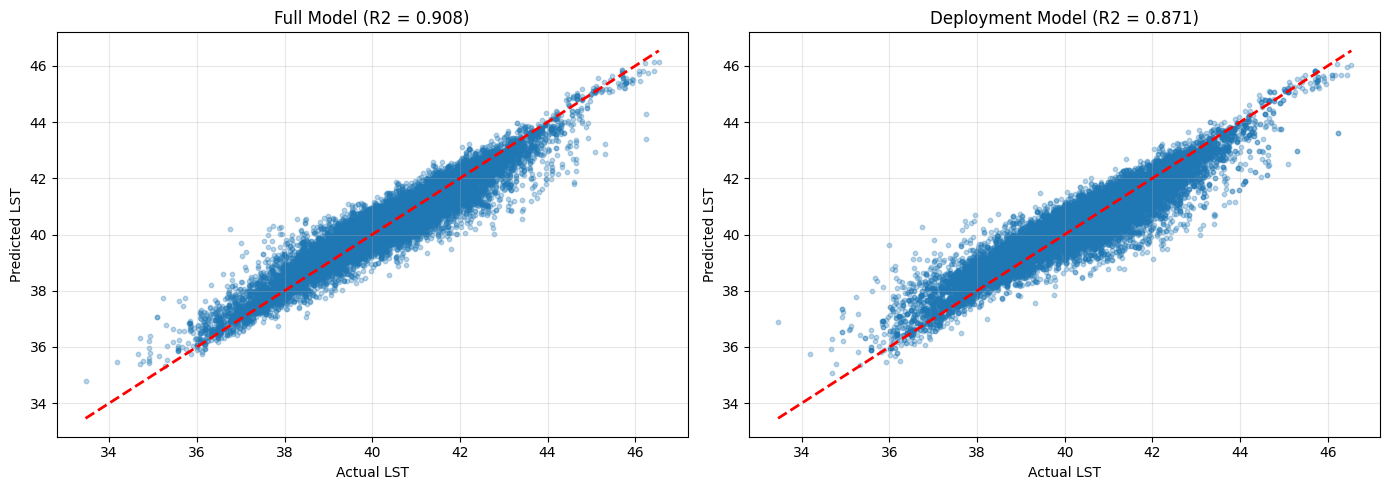

In [22]:
# Visualize predictions.
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Full model.
axes[0].scatter(y_full, y_pred_full, alpha = 0.3, s = 10)
axes[0].plot([y_full.min(), y_full.max()], [y_full.min(), y_full.max()], "r--", lw = 2)
axes[0].set_xlabel("Actual LST")
axes[0].set_ylabel("Predicted LST")
axes[0].set_title(f"Full Model (R2 = {train_r2:.3f})")
axes[0].grid(alpha = 0.3)

# Deployment model.
axes[1].scatter(y_deploy, y_pred_deploy, alpha = 0.3, s = 10)
axes[1].plot([y_deploy.min(), y_deploy.max()], [y_deploy.min(), y_deploy.max()], "r--", lw = 2)
axes[1].set_xlabel("Actual LST")
axes[1].set_ylabel("Predicted LST")
axes[1].set_title(f"Deployment Model (R2 = {train_r2_deploy:.3f})")
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

## SAVE MODELS

In [23]:
# Save full model.
with open(FULL_MODEL, "wb") as f:
    pickle.dump({
        "model": model_full,
        "features": ALL_FEATURES,
        "target": target,
        "cv_rmse": avg_rmse,
        "cv_r2": avg_r2,
        "cv_mae": avg_mae
    }, f)

print(f"Full model saved: {FULL_MODEL}")

# Save deployment model.
with open(DEPLOYMENT_MODEL, "wb") as f:
    pickle.dump({
        "model": model_deploy,
        "features": SHARED_FEATURES,
        "target": target,
        "cv_rmse": avg_rmse_deploy,
        "cv_r2": avg_r2_deploy,
        "cv_mae": avg_mae_deploy
    }, f)

print(f"Deployment model saved: {DEPLOYMENT_MODEL}")

# Save feature importance.
importance_combined = pd.concat([
    importance_full.assign(model = "full"),
    importance_deploy.assign(model = "deployment")
])

importance_combined.to_csv(FEATURE_IMPORTANCE, index = False)
print(f"Feature importance saved: {FEATURE_IMPORTANCE}")

Full model saved: models/xgboost_full_model.pkl
Deployment model saved: models/xgboost_deployment_model.pkl
Feature importance saved: models/feature_importance.csv
